# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/AI/Clase 6/TU_CARPETA")
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

assert PROJECT_DIR.exists(), f"No encuentro la carpeta del proyecto: {PROJECT_DIR}"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Verifica que existan las entradas de este challenge
required = [
    PROCESSED_DATA_DIR / "test.csv",
    ARTIFACTS_DIR / "data_contract.json",
    ARTIFACTS_DIR / "training_metadata.json",
    ARTIFACTS_DIR / "champion_model.joblib",
]
for p in required:
    print(("OK   " if p.exists() else "FALTA"), p)
assert all(p.exists() for p in required), "Faltan archivos de entrada, revisa PROJECT_DIR."

RANDOM_STATE = 42
print("PROJECT_DIR:", PROJECT_DIR)

Mounted at /content/drive
OK    /content/drive/MyDrive/AI/Clase 6/TU_CARPETA/data/processed/test.csv
OK    /content/drive/MyDrive/AI/Clase 6/TU_CARPETA/artifacts/data_contract.json
OK    /content/drive/MyDrive/AI/Clase 6/TU_CARPETA/artifacts/training_metadata.json
OK    /content/drive/MyDrive/AI/Clase 6/TU_CARPETA/artifacts/champion_model.joblib
PROJECT_DIR: /content/drive/MyDrive/AI/Clase 6/TU_CARPETA


## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: LogisticRegression
Test: (36, 13)


## 2. Evaluación final

Modelo: LogisticRegression
Accuracy test: 0.9722
F1 macro test: 0.9710
Accuracy CV (train): 0.9791

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        12
           1      0.933     1.000     0.966        14
           2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36



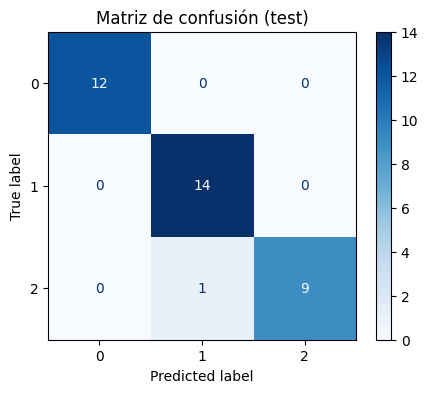

In [4]:
# Predicciones sobre test (única evaluación, modelo campeón ya entrenado)
y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Modelo: {training_metadata['champion']}")
print(f"Accuracy test: {test_accuracy:.4f}")
print(f"F1 macro test: {test_f1_macro:.4f}")
print(f"Accuracy CV (train): {training_metadata['cv_accuracy_mean']:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión (test)")
plt.show()

**Análisis:**

> ¿El desempeño es coherente con validación cruzada? ¿Qué clases se confunden? ¿Hay evidencia de sobreajuste?

¿El desempeño es coherente con validación cruzada? Sí. El accuracy en test (0.972) es casi igual al de CV (0.979); la diferencia de 0.007 es menor que el efecto de un solo error en 36 observaciones (≈ 0.028). El F1 macro (0.971) confirma que el rendimiento es parejo entre clases, no solo bueno en promedio.

¿Qué clases se confunden? Solo hay un error en todo el test: una muestra de la clase 2 fue predicha como clase 1. Por eso la clase 2 tiene recall de 0.900 (9 de 10) y la clase 1 tiene precision de 0.933 (14 de 15 predichas). La clase 0 se clasificó sin errores (12 de 12).

¿Hay evidencia de sobreajuste? No. El modelo mantiene en datos nunca vistos prácticamente el mismo desempeño que en validación, y la brecha train–validación en CV era pequeña (0.021). Si hubiera sobreajuste, el accuracy en test sería claramente menor que el de CV.

Salvedad: el test tiene solo 36 muestras, así que un único error mueve el accuracy unos 2.8 puntos. El resultado es consistente, pero no permite distinguir diferencias finas con alta confianza.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    if not isinstance(records, pd.DataFrame):
        raise TypeError("`records` debe ser un pandas DataFrame.")

    # 1. Verifica columnas faltantes
    missing = [c for c in feature_columns if c not in records.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    # 2. Ordena las columnas como en el entrenamiento (ignora columnas extra)
    X = records[feature_columns].copy()

    # 3. Verifica que todas sean numéricas
    non_numeric = [c for c in feature_columns if not pd.api.types.is_numeric_dtype(X[c])]
    if non_numeric:
        raise ValueError(f"Columnas no numéricas: {non_numeric}")

    # 4. Predicción y probabilidades
    preds = model.predict(X)
    probas = model.predict_proba(X)

    result = pd.DataFrame(
        probas,
        columns=[f"proba_class_{c}" for c in model.classes_],
        index=records.index,
    )
    result.insert(0, "prediction", preds)
    return result

## 4. Predicción por lotes

In [7]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

# Inferencia con validación de esquema
batch_results = predict(new_records)

# Guardamos las features junto con las predicciones
batch_predictions = pd.concat([new_records, batch_results], axis=1)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)

print("Guardado en:", REPORTS_DIR / "batch_predictions.csv")
batch_predictions[["prediction"] + [c for c in batch_predictions.columns if c.startswith("proba_")]]

Guardado en: /content/drive/MyDrive/AI/Clase 6/TU_CARPETA/reports/batch_predictions.csv


,prediction,proba_class_0,proba_class_1,proba_class_2
0,0,0.999671,0.000307,0.000023
1,1,0.007051,0.540423,0.452526
2,0,0.992000,0.007664,0.000336
3,1,0.289967,0.707467,0.002565
4,1,0.033032,0.962313,0.004655


## 5. Reporte final

In [8]:
test_metrics = {
    "model": training_metadata["champion"],
    "best_params": training_metadata["best_params"],
    "test_accuracy": float(test_accuracy),
    "test_f1_macro": float(test_f1_macro),
    "cv_accuracy_mean": float(training_metadata["cv_accuracy_mean"]),
    "n_test": int(len(y_test)),
}

with open(REPORTS_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)

print(json.dumps(test_metrics, indent=2, ensure_ascii=False))

{
  "model": "LogisticRegression",
  "best_params": {
    "model__C": 1
  },
  "test_accuracy": 0.9722222222222222,
  "test_f1_macro": 0.9709618874773139,
  "cv_accuracy_mean": 0.9790640394088669,
  "n_test": 36
}


In [9]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | |
| Accuracy CV | |
| Accuracy test | |
| F1 macro test | |
| Clases más confundidas | |
| Principal limitación | |

| Elemento | Resultado |
|---|---|
| Modelo campeón | Regresión Logística (C = 1) |
| Accuracy CV | 0.979 |
| Accuracy test | 0.972 |
| F1 macro test | 0.971 |
| Clases más confundidas | 2 → 1 (un caso) |
| Principal limitación | Test de solo 36 muestras y dataset pequeño (178 filas); un error mueve el accuracy unos 2.8 puntos |

## Checklist

- [ ] Evalué únicamente el modelo campeón.
- [ ] No reajusté hiperparámetros después de observar test.
- [ ] Implementé validación básica del esquema de entrada.
- [ ] Generé predicciones por lotes.
- [ ] Guardé las métricas finales.